# Car Price Prediction
**Task 3 - OASIS INFOBYTE Data Science Internship**

Predict the selling price of used cars based on features like year, present price, km driven, fuel type, transmission, and more.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
%matplotlib inline

---
## 1. Load the Dataset

In [2]:
df = pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [4]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


---
## 2. Exploratory Data Analysis

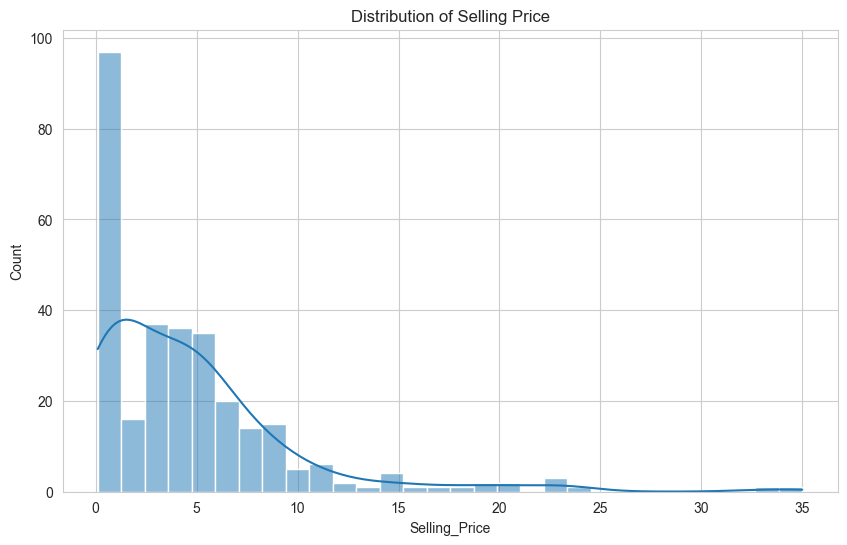

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Selling_Price'], bins=30, kde=True)
plt.title('Distribution of Selling Price')
plt.show()

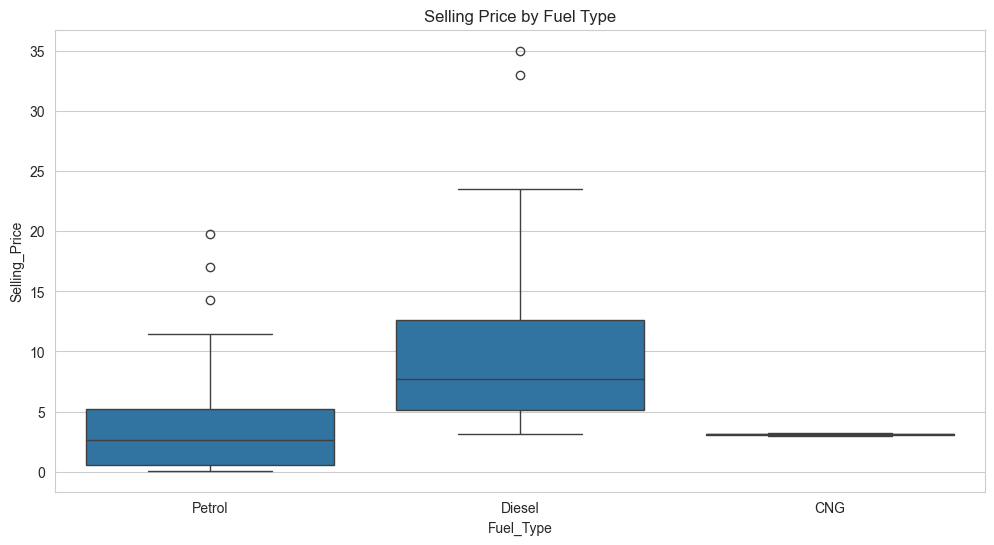

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price')
plt.title('Selling Price by Fuel Type')
plt.show()

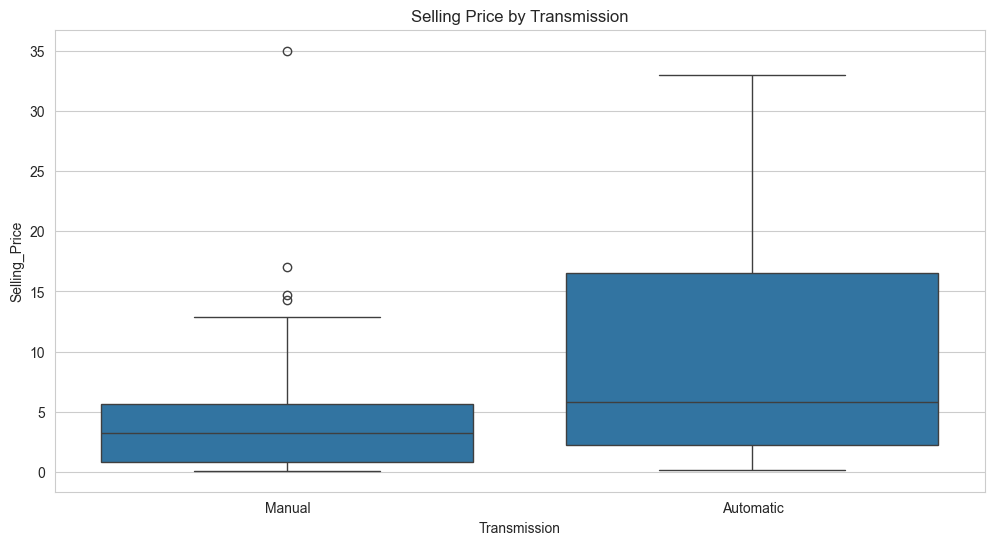

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Transmission', y='Selling_Price')
plt.title('Selling Price by Transmission')
plt.show()

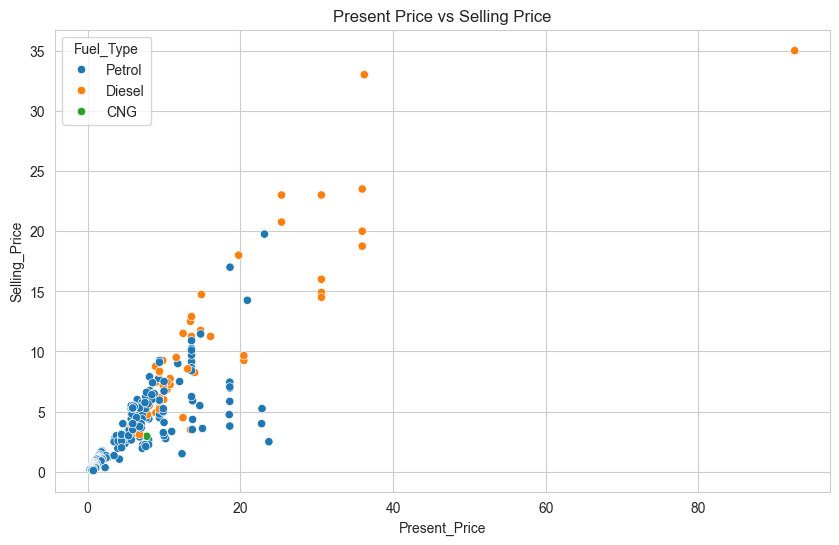

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price', hue='Fuel_Type')
plt.title('Present Price vs Selling Price')
plt.show()

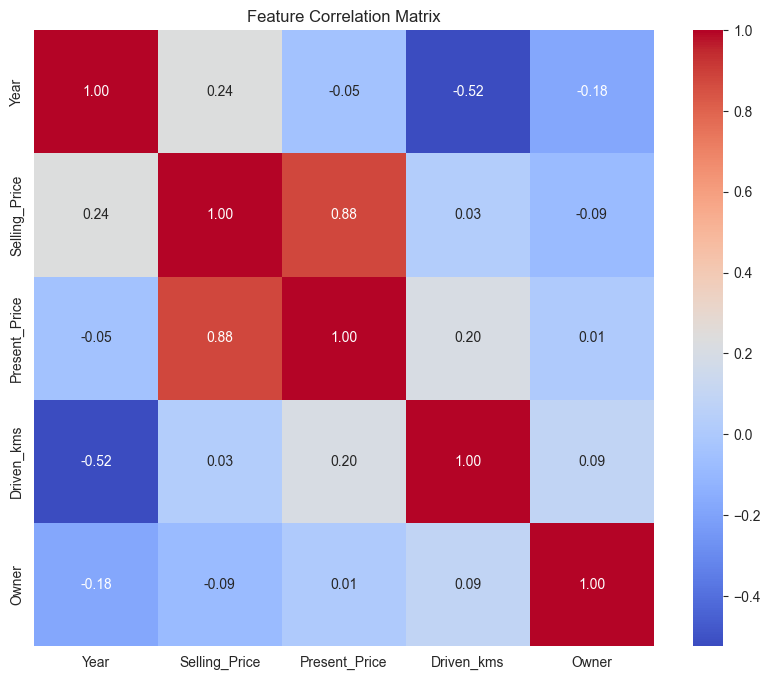

In [9]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

---
## 3. Data Preprocessing

In [10]:
# Drop Car_Name as it's not useful for prediction
df = df.drop(columns=['Car_Name'])

# Encode categorical variables
le = LabelEncoder()
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Selling_type'] = le.fit_transform(df['Selling_type'])
df['Transmission'] = le.fit_transform(df['Transmission'])

df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,3.35,5.59,27000,2,0,1,0
1,2013,4.75,9.54,43000,1,0,1,0
2,2017,7.25,9.85,6900,2,0,1,0
3,2011,2.85,4.15,5200,2,0,1,0
4,2014,4.60,6.87,42450,1,0,1,0


In [11]:
X = df.drop(columns=['Selling_Price'])
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')

Training samples: 240
Test samples: 61


---
## 4. Model Training & Evaluation

In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(alpha=0.1),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'R2 Score': r2, 'RMSE': rmse, 'MAE': mae}
    
    print(f'\n{"="*40}')
    print(f'{name}')
    print(f'R2 Score: {r2:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')


Linear Regression
R2 Score: 0.8467
RMSE: 1.8792
MAE: 1.2219

Lasso Regression
R2 Score: 0.8407
RMSE: 1.9156
MAE: 1.2315

Ridge Regression
R2 Score: 0.8462
RMSE: 1.8824
MAE: 1.2230

Random Forest
R2 Score: 0.9624
RMSE: 0.9312
MAE: 0.6211


In [13]:
results_df = pd.DataFrame(results).T
results_df

,R2 Score,RMSE,MAE
Linear Regression,0.846690,1.879250,1.221932
Lasso Regression,0.840701,1.915606,1.231494
Ridge Regression,0.846177,1.882394,1.223005
Random Forest,0.962354,0.931240,0.621108


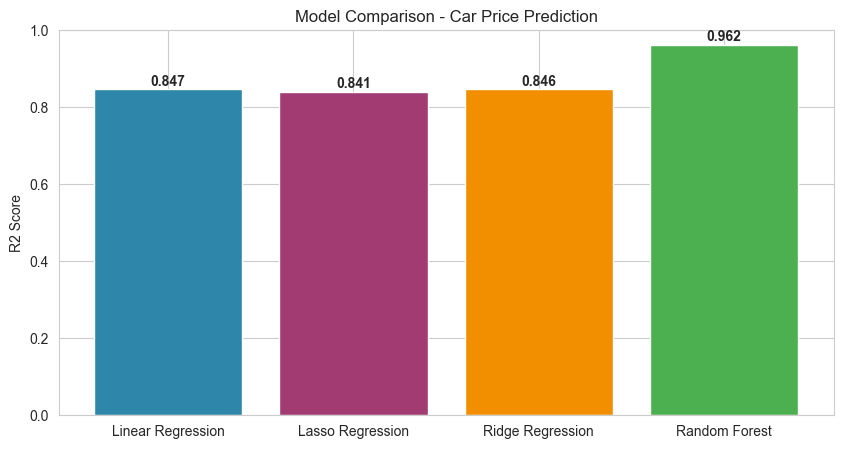

In [14]:
plt.figure(figsize=(10, 5))
bars = plt.bar(results_df.index, results_df['R2 Score'], color=['#2E86AB', '#A23B72', '#F18F01', '#4CAF50'])
plt.ylabel('R2 Score')
plt.title('Model Comparison - Car Price Prediction')
plt.ylim(0, 1)
for bar, val in zip(bars, results_df['R2 Score']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold')
plt.show()

---
## 5. Make a Prediction

In [15]:
best_model_name = results_df['R2 Score'].idxmax()
best_model = models[best_model_name]
print(f'Best model: {best_model_name} (R2: {results_df.loc[best_model_name, "R2 Score"]:.4f})')

# Sample prediction (first test sample)
sample = X_test_scaled[0:1]
pred = best_model.predict(sample)
actual = y_test.iloc[0]
print(f'Predicted Selling Price: {pred[0]:.2f} lakhs')
print(f'Actual Selling Price:    {actual:.2f} lakhs')

Best model: Random Forest (R2: 0.9624)
Predicted Selling Price: 0.44 lakhs
Actual Selling Price:    0.35 lakhs
